In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("listings.csv" )
df.info()
df

<class 'pandas.DataFrame'>
RangeIndex: 11551 entries, 0 to 11550
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              11551 non-null  int64  
 1   name                            11551 non-null  str    
 2   host_id                         11551 non-null  int64  
 3   host_name                       11528 non-null  str    
 4   neighbourhood_group             11551 non-null  str    
 5   neighbourhood                   11551 non-null  str    
 6   latitude                        11551 non-null  float64
 7   longitude                       11551 non-null  float64
 8   room_type                       11551 non-null  str    
 9   price                           7318 non-null   float64
 10  minimum_nights                  11551 non-null  int64  
 11  number_of_reviews               11551 non-null  int64  
 12  last_review                     9481 non-nu

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,222887,"Spectacular view, full air-con, elevator",1156398,Suzanne,Bordeaux,Bordeaux Sud,44.836102,-0.566395,Entire home/apt,167.0,3,114,2025-03-09,0.71,4,2,29,3306300031048
1,247452,"Cosy apartment ,barbecue, pool",959918,Krista,Saint-Mdard-en-Jalles,Saint-Mdard-en-Jalles,44.858900,-0.727350,Entire home/apt,115.0,2,78,2025-01-17,0.50,1,179,12,NaN
2,317273,"Luxury, spacious, patio, near public gardens",1156398,Suzanne,Bordeaux,Chartrons - Grand Parc - Jardin Public,44.847801,-0.581046,Entire home/apt,155.0,3,74,2025-02-02,0.57,4,0,18,33063001366CB
3,317658,"Key to Bordeaux · fairytale view, 2 bd + elevator",1156398,Suzanne,Bordeaux,Centre ville (Bordeaux),44.838799,-0.568870,Entire home/apt,204.0,3,155,2025-03-04,0.98,4,262,15,33063001225CF
4,333031,STUDIO BORDEAUX TRIANGLE D OR ***** Climatisé,1697156,Antony,Bordeaux,Centre ville (Bordeaux),44.842560,-0.577940,Entire home/apt,70.0,1,536,2025-02-21,3.40,2,0,46,3306300055979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11546,1362348833991989162,Idéal Voyageur & Travailleur - Calme avec Parking,108044276,Jérémy,Merignac,Capeyron,44.854134,-0.652047,Entire home/apt,47.0,4,0,NaN,NaN,1,326,0,NaN
11547,1362418079945305931,Maison familiale 5 ch Piscine,107218462,Sonia,Merignac,La Glacire,44.833716,-0.618516,Entire home/apt,330.0,7,0,NaN,NaN,1,365,0,NaN
11548,1362463803457737590,Appartement Entier 3 chambres,153601574,Rupestre,Pessac,Nos,44.812873,-0.635511,Entire home/apt,95.0,1,0,NaN,NaN,1,328,0,NaN
11549,1362847505842279110,Maison proche Bordeaux,85130263,Yaodia,Villenave-d'Ornon,Villenave-d'Ornon,44.775834,-0.544911,Entire home/apt,54.0,3,0,NaN,NaN,1,0,0,NaN


1.GESTION DES VALEURS MNAQUANTES

1.1) Identification des valeurs manquantes

In [11]:
#somme des valeurs manquantes par colonne
missing_values = df.isnull().sum()
print(missing_values)

id                                   0
name                                 0
host_id                              0
host_name                           23
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             4233
minimum_nights                       0
number_of_reviews                    0
last_review                       2070
reviews_per_month                 2070
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           7099
dtype: int64


In [15]:
#pourcentages des valeurs manquantes par colonne
missing_percentages = df.isnull().mean() * 100
print(missing_percentages)

id                                 0.000000
name                               0.000000
host_id                            0.000000
host_name                          0.199117
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                             36.646178
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       17.920526
reviews_per_month                 17.920526
calculated_host_listings_count     0.000000
availability_365                   0.000000
number_of_reviews_ltm              0.000000
license                           61.457882
dtype: float64


1.2) Traitement des colonnes concernés

In [28]:
df['reviews_per_month'].fillna(0, inplace=True)
df.dropna(subset=['last_review'], inplace=True)
print(df.shape)

(9481, 18)


C:\Users\redaa\AppData\Local\Temp\ipykernel_11908\2880957359.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['reviews_per_month'].fillna(0, inplace=True)


2.Nettoyage des dates

In [30]:
df['last_review'] = pd.to_datetime(df['last_review'] ,errors='coerce')
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,222887,"Spectacular view, full air-con, elevator",1156398,Suzanne,Bordeaux,Bordeaux Sud,44.836102,-0.566395,Entire home/apt,167.0,3,114,2025-03-09,0.71,4,2,29,3306300031048
1,247452,"Cosy apartment ,barbecue, pool",959918,Krista,Saint-Mdard-en-Jalles,Saint-Mdard-en-Jalles,44.858900,-0.727350,Entire home/apt,115.0,2,78,2025-01-17,0.50,1,179,12,NaN
2,317273,"Luxury, spacious, patio, near public gardens",1156398,Suzanne,Bordeaux,Chartrons - Grand Parc - Jardin Public,44.847801,-0.581046,Entire home/apt,155.0,3,74,2025-02-02,0.57,4,0,18,33063001366CB
3,317658,"Key to Bordeaux · fairytale view, 2 bd + elevator",1156398,Suzanne,Bordeaux,Centre ville (Bordeaux),44.838799,-0.568870,Entire home/apt,204.0,3,155,2025-03-04,0.98,4,262,15,33063001225CF
4,333031,STUDIO BORDEAUX TRIANGLE D OR ***** Climatisé,1697156,Antony,Bordeaux,Centre ville (Bordeaux),44.842560,-0.577940,Entire home/apt,70.0,1,536,2025-02-21,3.40,2,0,46,3306300055979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11502,1355875051549605939,off,77319372,Sandrine,Villenave-d'Ornon,Villenave-d'Ornon,44.791977,-0.568798,Entire home/apt,NaN,1,1,2025-02-16,1.00,2,0,1,NaN
11504,1356518184970760391,"Grand T4 lumineux, tram, parking",665570793,Hocine,Bordeaux,Bordeaux Sud,44.816395,-0.552397,Entire home/apt,146.0,1,2,2025-03-05,2.00,1,74,2,330630129848C
11506,1357114346290310869,4 pers | 15' aéroport/centre | Balcon | Parkin...,153730213,Nicolas,Merignac,La Glacire,44.827751,-0.614712,Entire home/apt,57.0,1,1,2025-03-09,1.00,1,199,1,NaN
11511,1357968949107696883,Chambre à Mérignac,569277525,Elise,Merignac,Centre ville (Merignac),44.845700,-0.667392,Private room,45.0,1,1,2025-02-27,1.00,1,4,1,NaN


In [31]:
df[df['last_review'].isnull()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license


3.Encodage des variables categorielles

In [34]:
df['room_type'].value_counts()

room_type
Entire home/apt    7440
Private room       1998
Shared room          32
Hotel room           11
Name: count, dtype: int64

In [37]:
df_encodage=pd.get_dummies(df, columns=['room_type' , 'neighbourhood'] ,drop_first=True) 
df_encodage

,id,name,host_id,host_name,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,...,neighbourhood_Saint Augustin - Tauzin - Alphonse Dupeux,neighbourhood_Saint-Aubin-de-Mdoc,neighbourhood_Saint-Louis-de-Montferrand,neighbourhood_Saint-Mdard-en-Jalles,neighbourhood_Saint-Vincent-de-Paul,neighbourhood_Sardine,neighbourhood_Talence,neighbourhood_Toctoucau,neighbourhood_Verthamon,neighbourhood_Villenave-d'Ornon
0,222887,"Spectacular view, full air-con, elevator",1156398,Suzanne,Bordeaux,44.836102,-0.566395,167.0,3,114,...,False,False,False,False,False,False,False,False,False,False
1,247452,"Cosy apartment ,barbecue, pool",959918,Krista,Saint-Mdard-en-Jalles,44.858900,-0.727350,115.0,2,78,...,False,False,False,True,False,False,False,False,False,False
2,317273,"Luxury, spacious, patio, near public gardens",1156398,Suzanne,Bordeaux,44.847801,-0.581046,155.0,3,74,...,False,False,False,False,False,False,False,False,False,False
3,317658,"Key to Bordeaux · fairytale view, 2 bd + elevator",1156398,Suzanne,Bordeaux,44.838799,-0.568870,204.0,3,155,...,False,False,False,False,False,False,False,False,False,False
4,333031,STUDIO BORDEAUX TRIANGLE D OR ***** Climatisé,1697156,Antony,Bordeaux,44.842560,-0.577940,70.0,1,536,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11502,1355875051549605939,off,77319372,Sandrine,Villenave-d'Ornon,44.791977,-0.568798,NaN,1,1,...,False,False,False,False,False,False,False,False,False,True
11504,1356518184970760391,"Grand T4 lumineux, tram, parking",665570793,Hocine,Bordeaux,44.816395,-0.552397,146.0,1,2,...,False,False,False,False,False,False,False,False,False,False
11506,1357114346290310869,4 pers | 15' aéroport/centre | Balcon | Parkin...,153730213,Nicolas,Merignac,44.827751,-0.614712,57.0,1,1,...,False,False,False,False,False,False,False,False,False,False
11511,1357968949107696883,Chambre à Mérignac,569277525,Elise,Merignac,44.845700,-0.667392,45.0,1,1,...,False,False,False,False,False,False,False,False,False,False


4.Analyse des ecarts-types

4.1) Statistiques descriptives

In [39]:
df[['price','minimum_nights','number_of_reviews','availability_365']].describe()

,price,minimum_nights,number_of_reviews,availability_365
count,6213.000000,9481.000000,9481.000000,9481.000000
mean,112.001770,38.232359,42.364729,112.717013
std,266.831226,107.823122,81.103881,130.284559
min,9.000000,1.000000,1.000000,0.000000
25%,51.000000,1.000000,5.000000,0.000000
50%,75.000000,2.000000,15.000000,53.000000
75%,120.000000,4.000000,44.000000,229.000000
max,9429.000000,999.000000,1150.000000,365.000000


4.2) Calcul des ecarts-types

In [40]:
df[['price','minimum_nights','number_of_reviews','availability_365']].std()

price                266.831226
minimum_nights       107.823122
number_of_reviews     81.103881
availability_365     130.284559
dtype: float64

5. Detection des outliers

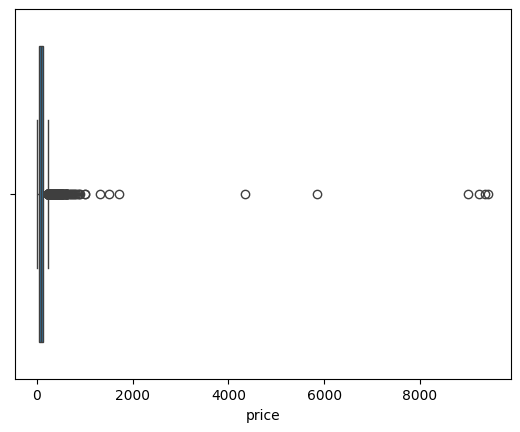

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='price', data=df)
plt.show()

In [50]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
lower_bound = Q1 - 1.5 * IQR
print(f"Lower Bound: {lower_bound}")
upper_bond = Q3 + 1.5 * IQR
print(f"Upper Bound: {upper_bond}")
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bond)]
outliers


Q1: 51.0
Q3: 120.0
IQR: 69.0
Lower Bound: -52.5
Upper Bound: 223.5


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
9,482102,Beautiful city house full comfort,2387430,Frederic,Le Bouscat,Le Bouscat,44.854200,-0.595810,Entire home/apt,224.0,2,488,2025-03-02,3.17,1,0,32,NaN
27,856891,Maison d'architecte de caractère,1924713,Jean-François,Bordeaux,Caudran,44.859460,-0.612380,Entire home/apt,389.0,2,104,2024-09-22,0.93,1,2,11,3306300088213
29,872870,"Esprit Zen, till 8 pax, 4 rooms, Bordeaux center",4561878,Béatrice & Sébastien,Bordeaux,Bordeaux Sud,44.833050,-0.575090,Entire home/apt,228.0,2,92,2024-12-15,0.65,5,235,3,3306301168657
33,881775,"House Sebea (10 people) with pool, Bordeaux-Sud",4561878,Béatrice & Sébastien,Gradignan,Gradignan,44.754650,-0.622960,Entire home/apt,360.0,7,3,2022-08-27,0.02,5,15,0,NaN
34,881940,"Large cottage with swim. pool, Bordeaux-south,...",4561878,Béatrice & Sébastien,Gradignan,Gradignan,44.753880,-0.622800,Entire home/apt,374.0,2,41,2024-07-27,0.29,5,0,4,1710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10748,1275297262419188365,Adagio - Studio 2 People,561155500,Xavier Frédéric Patrice,Bordeaux,Saint Augustin - Tauzin - Alphonse Dupeux,44.834270,-0.585260,Entire home/apt,9238.0,1,3,2025-01-31,1.43,1,365,3,Exempt - hotel-type listing
10774,1252188569792443337,Belle villa dans un environnement arboré,511865493,Irène,Saint-Mdard-en-Jalles,Saint-Mdard-en-Jalles,44.886514,-0.706848,Entire home/apt,261.0,3,2,2025-01-01,0.83,2,40,2,NaN
10858,1282482880549863332,Villa Châtelet,93820028,Lisa,Pessac,France Alouette,44.788387,-0.673888,Entire home/apt,350.0,7,2,2025-01-04,0.83,1,0,2,NaN
10960,1288906367287846722,Le rooftop de la Faïencerie,451644543,Alexandre,Bordeaux,Bordeaux Maritime,44.862314,-0.558249,Entire home/apt,240.0,1,3,2025-02-09,0.98,1,86,3,33063012660EC


6.Supression des outliers

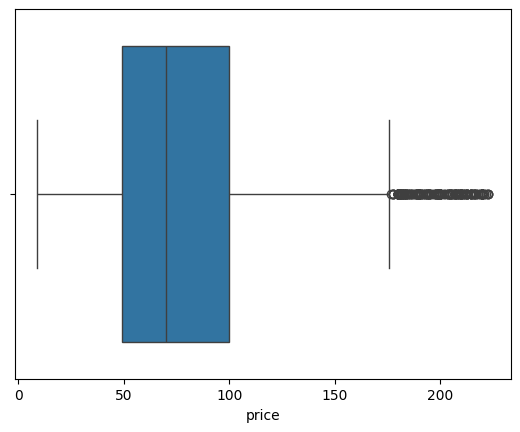

In [ ]:
df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bond)]
sns.boxplot(x='price', data=df_clean)
plt.show()

In [52]:
df_clean

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,222887,"Spectacular view, full air-con, elevator",1156398,Suzanne,Bordeaux,Bordeaux Sud,44.836102,-0.566395,Entire home/apt,167.0,3,114,2025-03-09,0.71,4,2,29,3306300031048
1,247452,"Cosy apartment ,barbecue, pool",959918,Krista,Saint-Mdard-en-Jalles,Saint-Mdard-en-Jalles,44.858900,-0.727350,Entire home/apt,115.0,2,78,2025-01-17,0.50,1,179,12,NaN
2,317273,"Luxury, spacious, patio, near public gardens",1156398,Suzanne,Bordeaux,Chartrons - Grand Parc - Jardin Public,44.847801,-0.581046,Entire home/apt,155.0,3,74,2025-02-02,0.57,4,0,18,33063001366CB
3,317658,"Key to Bordeaux · fairytale view, 2 bd + elevator",1156398,Suzanne,Bordeaux,Centre ville (Bordeaux),44.838799,-0.568870,Entire home/apt,204.0,3,155,2025-03-04,0.98,4,262,15,33063001225CF
4,333031,STUDIO BORDEAUX TRIANGLE D OR ***** Climatisé,1697156,Antony,Bordeaux,Centre ville (Bordeaux),44.842560,-0.577940,Entire home/apt,70.0,1,536,2025-02-21,3.40,2,0,46,3306300055979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,1355577012530341861,"Les surfeuses, à 2,5 kms de Bordeaux.",77319372,Sandrine,Villenave-d'Ornon,Villenave-d'Ornon,44.792257,-0.569404,Entire home/apt,85.0,1,4,2025-03-09,4.00,2,325,4,NaN
11504,1356518184970760391,"Grand T4 lumineux, tram, parking",665570793,Hocine,Bordeaux,Bordeaux Sud,44.816395,-0.552397,Entire home/apt,146.0,1,2,2025-03-05,2.00,1,74,2,330630129848C
11506,1357114346290310869,4 pers | 15' aéroport/centre | Balcon | Parkin...,153730213,Nicolas,Merignac,La Glacire,44.827751,-0.614712,Entire home/apt,57.0,1,1,2025-03-09,1.00,1,199,1,NaN
11511,1357968949107696883,Chambre à Mérignac,569277525,Elise,Merignac,Centre ville (Merignac),44.845700,-0.667392,Private room,45.0,1,1,2025-02-27,1.00,1,4,1,NaN
